# Adult Census Income Prediction
## End-to-End Machine Learning Project

**Goal:** predict whether a person's annual income exceeds **$50K** based on census data
(`income` = `<=50K` or `>50K`).

This notebook follows the same professional workflow used in the Hotel Booking
Cancellation project: data understanding -> cleaning -> class-imbalance-aware modeling ->
smart encoding -> EDA -> model comparison -> hyperparameter tuning -> feature selection ->
final evaluation -> saved deployment artifacts.


# **Part 1 - Imports**

In [3]:
# ============================================================
# Part 1.1 : Imports
# ============================================================
!pip install -q catboost lightgbm xgboost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


# **Part 2 - Load & Understand the Data**

In [4]:
# ============================================================
# Part 2.1 : Load Dataset
# ============================================================

df = pd.read_csv("/content/Adult Census Income.csv", na_values=["?"])

df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Part 2.2 : Shape
df.shape


(32561, 15)

In [6]:
# Part 2.3 : Data Types & Non-Null Counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
# Part 2.4 : Statistical Summary
df.describe(include="all")


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,30725,3.256100e+04,32561,32561.000000,32561,30718,32561,32561,32561,32561.000000,32561.000000,32561.000000,31978,32561
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [8]:
# Part 2.5 : Missing Values Per Column
df.isnull().sum().sort_values(ascending=False)


,0
occupation,1843
workclass,1836
native.country,583
fnlwgt,0
education,0
education.num,0
age,0
marital.status,0
relationship,0
sex,0


**Observation:** missing values (encoded as `?` in the raw file, converted to `NaN`
above) only appear in three categorical columns: `workclass`, `occupation`, and
`native.country`. All numeric columns are fully populated.

In [9]:
# Part 2.6 : Duplicate Rows
df.duplicated().sum()


np.int64(24)

In [10]:
# ============================================================
# Part 2.7 : Remove Duplicates
# ============================================================

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

df.shape


(32537, 15)

# **Part 3 - Train / Test Split**

Splitting *before* imputation, encoding, and scaling avoids data leakage - every
preprocessing object below is fit only on the training set, then applied to the test
set, exactly like the hotel-booking project.

In [11]:
# ============================================================
# Part 3.1 : Split Features & Target
# ============================================================

X = df.drop(columns=["income"])
y = df["income"]


In [12]:
# ============================================================
# Part 3.2 : Train / Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    stratify=y,
    random_state=42
)

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (26029, 14)  X_test: (6508, 14)


# **Part 4 - Class Imbalance**

### Handling Class Imbalance

`income` is imbalanced - about **76% `<=50K`** vs **24% `>50K`**. Left untreated, models
default to predicting the majority class more often and under-detect higher earners. As
with the hotel-cancellation project, this is handled at the **model level** (native
class-weighting) rather than by resampling the data:

- `class_weight="balanced"` for Logistic Regression, Decision Tree, Random Forest, Extra Trees
- `scale_pos_weight` (negative/positive ratio) for XGBoost
- `class_weight="balanced"` for LightGBM
- `auto_class_weights="Balanced"` for CatBoost

The ratio is computed once here, right after the split (so `y_train` already exists),
and reused everywhere below.

In [13]:
# ============================================================
# Part 4.1 : Compute Class Weighting Ratio
# ============================================================

class_counts = y_train.value_counts()

scale_pos_weight = class_counts["<=50K"] / class_counts[">50K"]

print("Class distribution in y_train:")
print(class_counts)
print()
print(f"scale_pos_weight (neg/pos) = {scale_pos_weight:.4f}")


Class distribution in y_train:
income
<=50K    19758
>50K      6271
Name: count, dtype: int64

scale_pos_weight (neg/pos) = 3.1507


# **Part 5 - Handle Missing Values**

In [14]:
# ============================================================
# Part 5.1 : Impute Missing Categorical Values (Most Frequent)
# ============================================================
# Fit on train only, then apply the SAME fitted imputer to test - avoids leakage.

categorical_imputer = SimpleImputer(strategy="most_frequent")

missing_cols = ["workclass", "occupation", "native.country"]

X_train[missing_cols] = categorical_imputer.fit_transform(X_train[missing_cols])
X_test[missing_cols] = categorical_imputer.transform(X_test[missing_cols])

X_train.isnull().sum().sum(), X_test.isnull().sum().sum()


(np.int64(0), np.int64(0))

# **Part 6 - Exploratory Data Analysis**

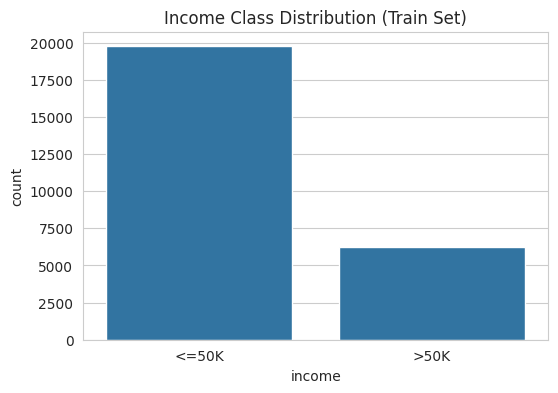

,proportion
income,
<=50K,75.907641
>50K,24.092359


In [15]:
# Part 6.1 : Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Income Class Distribution (Train Set)")
plt.show()

y_train.value_counts(normalize=True) * 100


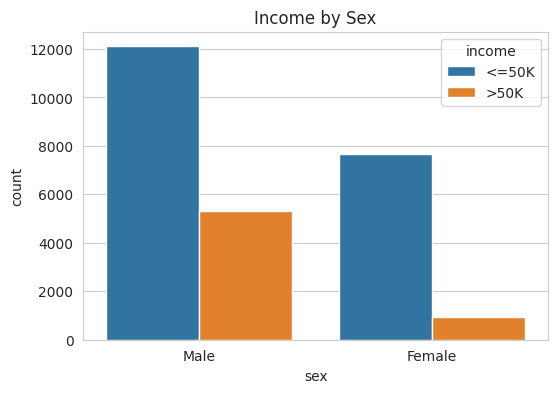

In [16]:
# Part 6.2 : Income by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x=X_train["sex"], hue=y_train)
plt.title("Income by Sex")
plt.show()


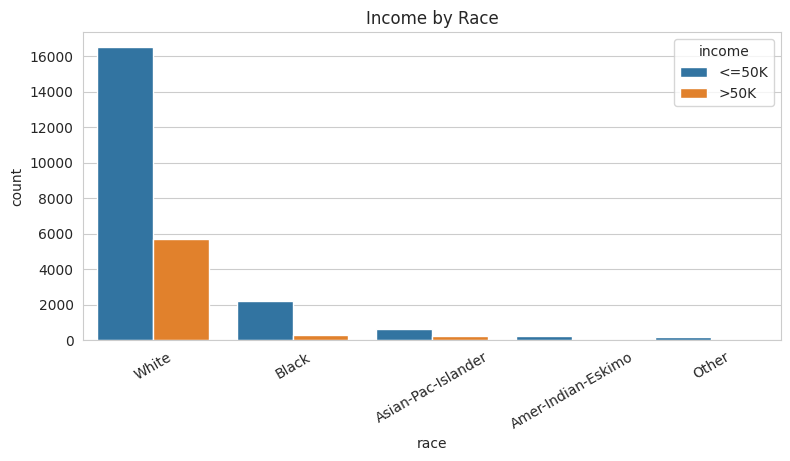

In [17]:
# Part 6.3 : Income by Race
plt.figure(figsize=(9, 4))
sns.countplot(x=X_train["race"], hue=y_train)
plt.title("Income by Race")
plt.xticks(rotation=30)
plt.show()


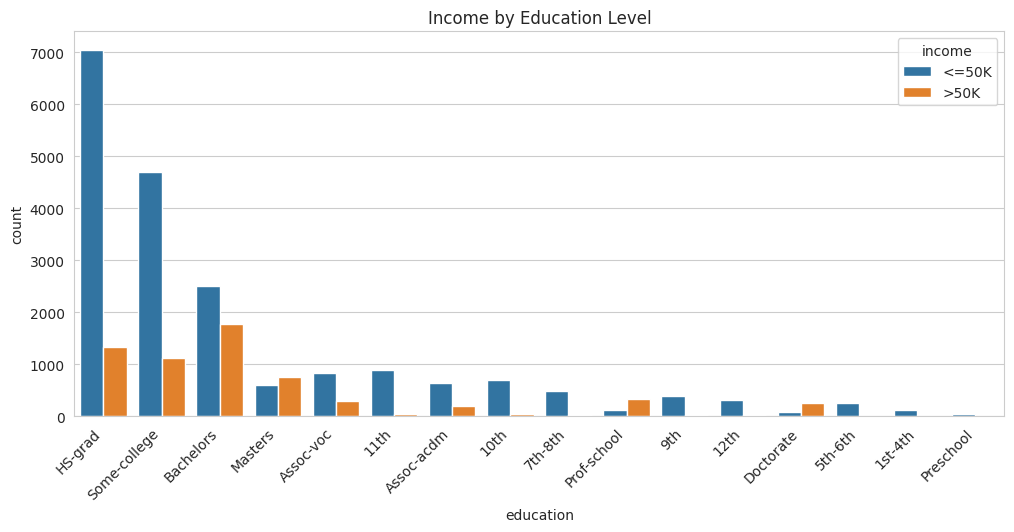

In [18]:
# Part 6.4 : Income by Education Level
order = X_train.groupby(X_train["education"])["education"].count().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.countplot(x=X_train["education"], hue=y_train, order=order)
plt.title("Income by Education Level")
plt.xticks(rotation=45, ha="right")
plt.show()


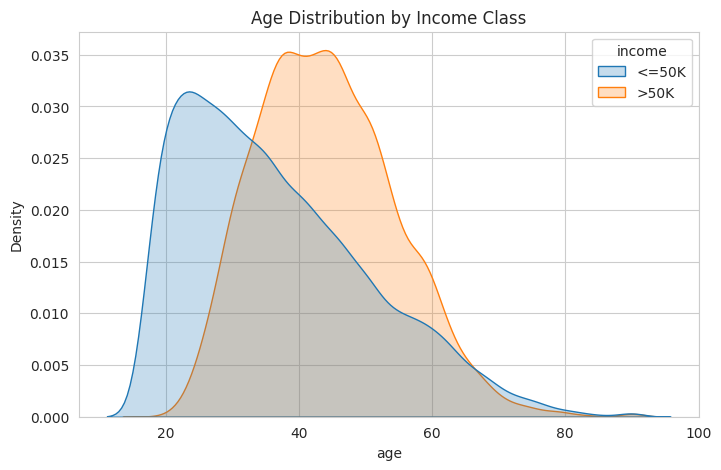

In [19]:
# Part 6.5 : Age Distribution vs Income
plt.figure(figsize=(8, 5))
sns.kdeplot(data=X_train.assign(income=y_train.values), x="age", hue="income", fill=True, common_norm=False)
plt.title("Age Distribution by Income Class")
plt.show()


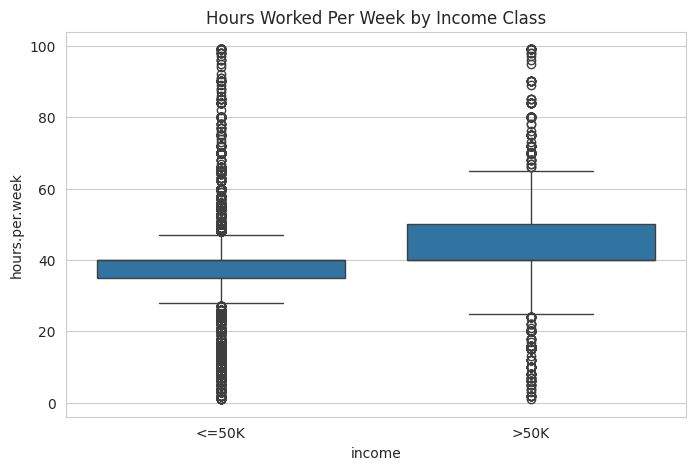

In [20]:
# Part 6.6 : Hours Per Week vs Income
plt.figure(figsize=(8, 5))
sns.boxplot(x=y_train, y=X_train["hours.per.week"])
plt.title("Hours Worked Per Week by Income Class")
plt.show()


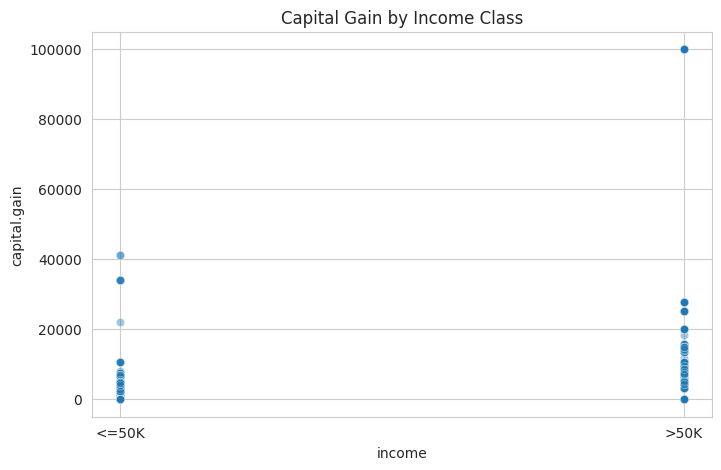

In [21]:
# Part 6.7 : Capital Gain vs Income
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_train, y=X_train["capital.gain"], alpha=0.4)
plt.title("Capital Gain by Income Class")
plt.show()


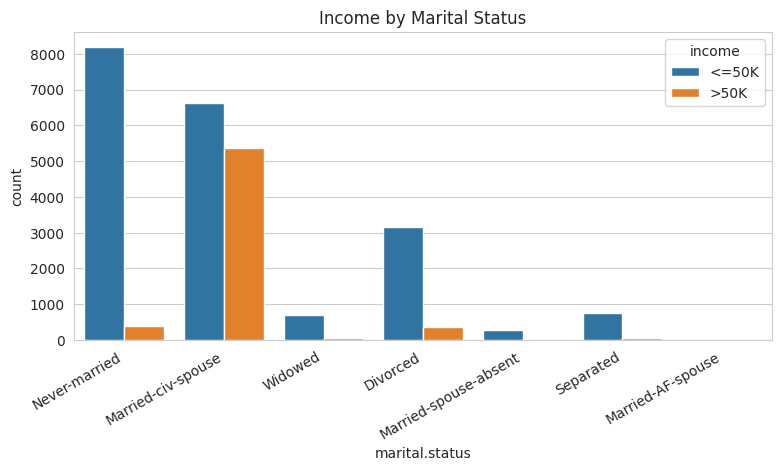

In [22]:
# Part 6.8 : Marital Status vs Income
plt.figure(figsize=(9, 4))
sns.countplot(x=X_train["marital.status"], hue=y_train)
plt.title("Income by Marital Status")
plt.xticks(rotation=30, ha="right")
plt.show()


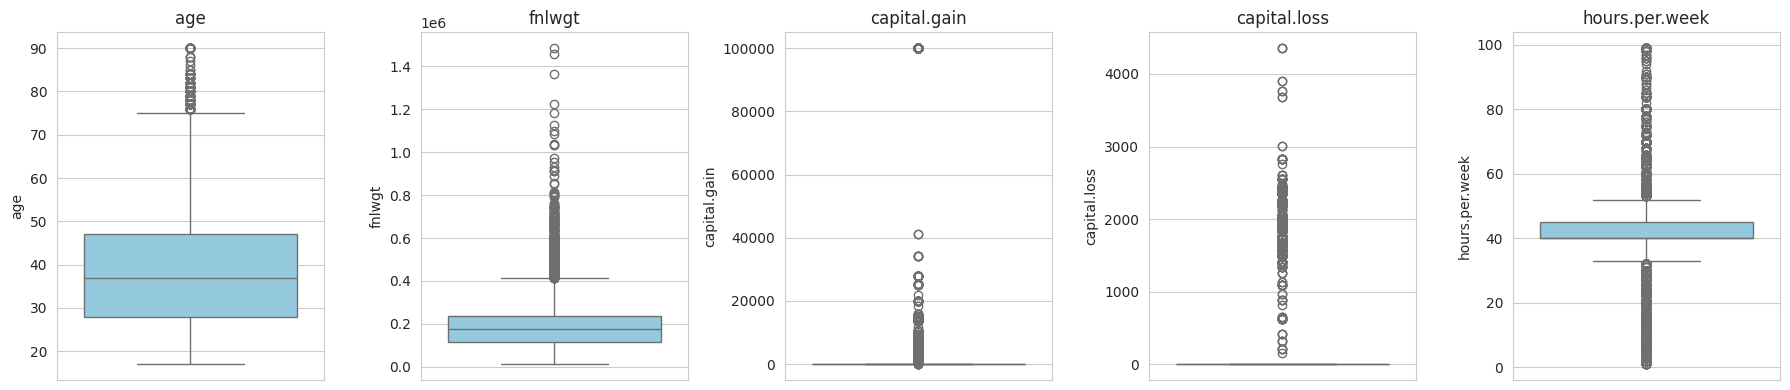

In [23]:
# Part 6.9 : Outlier Inspection (Numeric Features)
num_preview = ["age", "fnlwgt", "capital.gain", "capital.loss", "hours.per.week"]

fig, axes = plt.subplots(1, len(num_preview), figsize=(18, 4))
for ax, col in zip(axes, num_preview):
    sns.boxplot(y=X_train[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**EDA Insights:**
- The dataset is imbalanced (~76% `<=50K` vs ~24% `>50K`), confirmed by the target plot above.
- Higher education levels (Bachelors, Masters, Doctorate, Prof-school) show a visibly higher share of `>50K` earners than HS-grad or lower levels.
- `capital.gain` and `capital.loss` are extremely skewed - most people report 0, but a small group has large gains, and that group is almost entirely `>50K`.
- `hours.per.week` trends higher for `>50K` earners, consistent with more full-time / overtime roles.
- `fnlwgt` is a census sampling weight, not a personal attribute - it carries little direct predictive meaning about an individual's income, so it will be handled carefully in feature-importance review later.
- Several numeric columns (`capital.gain`, `capital.loss`, `fnlwgt`) show heavy outlier tails, similar to `lead_time`/`adr` in the hotel project - kept as-is since tree-based models are robust to them.

# **Part 7 - Smart Encoding Strategy**

Same feature-specific approach as the hotel-booking project instead of one blanket
encoding scheme:

- **Drop `education`** - fully redundant with `education.num` (a 1-to-1 mapping already
  confirmed on the raw data), so keeping both would double-count the same information.
- **Label Encoding** - for `workclass`, `marital.status`, `occupation`, `relationship`,
  `race`, `sex` (moderate cardinality, tree-based models handle the arbitrary ordering fine).
- **Frequency Encoding** - for `native.country` (41 unique values). Instead of dropping it
  entirely (which throws away information), it is frequency-encoded exactly like `country`
  in the hotel project - this avoids a huge one-hot matrix while still preserving signal
  about how common each country is.
- **Target Encoding** - `income` is mapped explicitly to `{"<=50K": 0, ">50K": 1}` rather
  than relying on `LabelEncoder`'s implicit alphabetical ordering, so the meaning of class
  `1` is unambiguous everywhere downstream (recall, precision, etc. all refer to correctly
  predicting `>50K`).

Every encoder is fit on the training set only and stored in a dictionary so it can be
reused identically on the test set and saved for deployment.

In [24]:
# ============================================================
# Part 7.1 : Drop Redundant Column
# ============================================================

X_train.drop(columns=["education"], inplace=True)
X_test.drop(columns=["education"], inplace=True)


In [25]:
# ============================================================
# Part 7.2 : Frequency Encode native.country
# ============================================================

country_frequency = X_train["native.country"].value_counts(normalize=True)

X_train["native.country"] = X_train["native.country"].map(country_frequency)
X_test["native.country"] = X_test["native.country"].map(country_frequency).fillna(0)


In [26]:
# ============================================================
# Part 7.3 : Label Encode Categorical Columns
# ============================================================

label_columns = ["workclass", "marital.status", "occupation", "relationship", "race", "sex"]

label_encoders = {}

for col in label_columns:
    encoder = LabelEncoder()
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])
    label_encoders[col] = encoder

X_train.head()


,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,21,3,140012,10,4,9,3,4,1,0,0,20,0.914480
1,41,3,433989,11,2,11,0,4,1,4386,0,60,0.914480
2,24,3,241951,9,4,5,4,2,0,0,0,40,0.914480
3,59,3,99131,9,6,9,1,4,0,0,0,18,0.914480
4,35,3,267866,9,2,11,0,1,1,0,1887,50,0.001306


In [27]:
# ============================================================
# Part 7.4 : Encode Target Explicitly
# ============================================================

income_map = {"<=50K": 0, ">50K": 1}

y_train = y_train.map(income_map)
y_test = y_test.map(income_map)

y_train.value_counts()


,count
income,
0,19758
1,6271


# **Part 8 - Correlation with the Target**

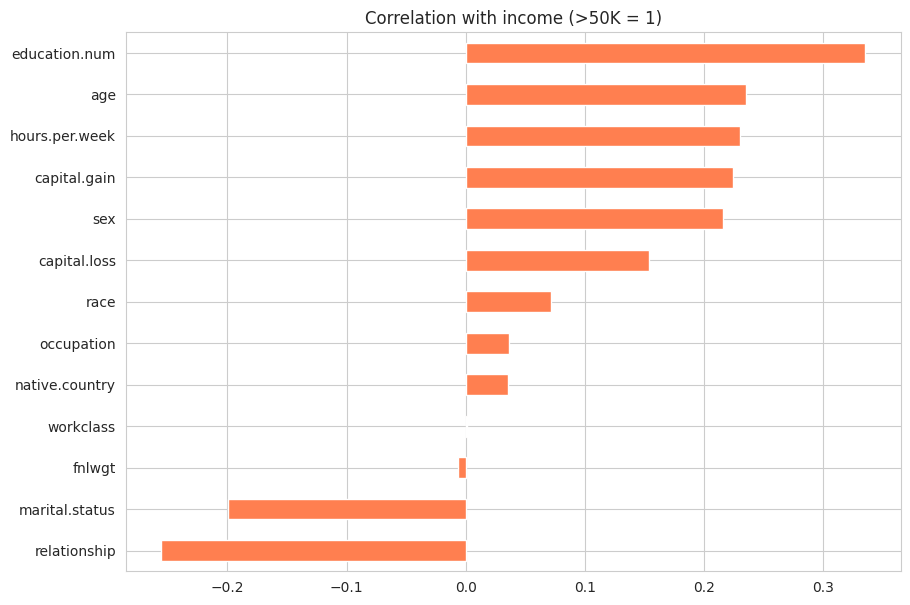

In [28]:
plt.figure(figsize=(10, 7))

corr = X_train.assign(income=y_train.values).corr()["income"].drop("income").sort_values()

corr.plot(kind="barh", color="coral")
plt.title("Correlation with income (>50K = 1)")
plt.show()


**Insight:** `education.num`, `age`, `hours.per.week`, and `capital.gain` show the
strongest positive correlation with earning `>50K` - consistent with the EDA plots above.
`fnlwgt` shows almost no correlation, confirming it is not personally predictive.

# **Part 9 - Feature Scaling**

In [29]:
# ============================================================
# Part 9.1 : Scale Numerical Columns
# ============================================================

numeric_cols = [
    "age", "fnlwgt", "education.num", "capital.gain",
    "capital.loss", "hours.per.week"
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head()


,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,-1.285119,3,-0.470627,-0.031109,4,9,3,4,1,-0.146741,-0.217980,-1.663470,0.914480
1,0.183261,3,2.306554,0.357626,2,11,0,4,1,0.440673,-0.217980,1.592035,0.914480
2,-1.064862,3,0.492384,-0.419844,4,5,4,2,0,-0.146741,-0.217980,-0.035717,0.914480
3,1.504803,3,-0.856828,-0.419844,6,9,1,4,0,-0.146741,-0.217980,-1.826245,0.914480
4,-0.257253,3,0.737201,-0.419844,2,11,0,1,1,-0.146741,4.422739,0.778159,0.001306


# **Part 10 - Classification Models Comparison**

Eleven algorithms are trained and compared on identical data, with class-imbalance
handling built into every model that supports it (see Part 4).

In [30]:
# ============================================================
# Part 10.1 : Classification Models
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42, max_iter=2000, class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42, class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42, class_weight="balanced"
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42, class_weight="balanced"
    ),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "Gaussian NB": GaussianNB(),

    "XGBoost": XGBClassifier(
        random_state=42, eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ),

    "LightGBM": LGBMClassifier(
        random_state=42, verbose=-1, class_weight="balanced"
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42, verbose=False, auto_class_weights="Balanced"
    )

}

print(f"Total Models : {len(models)}")


Total Models : 11


In [31]:
# ============================================================
# Part 10.2 : Train & Evaluate Every Model
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        test_prob = model.predict_proba(X_test)[:, 1]
    else:
        test_prob = model.decision_function(X_test)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1 Score": f1_score(y_test, test_pred),
        "ROC AUC": roc_auc_score(y_test, test_prob)
    })

    trained_models[name] = model

    print(f"{name:22s} done.")


Logistic Regression    done.
KNN                    done.
Decision Tree          done.
Random Forest          done.
Extra Trees            done.
AdaBoost               done.
Gradient Boosting      done.
Gaussian NB            done.
XGBoost                done.
LightGBM               done.
CatBoost               done.


In [32]:
# ============================================================
# Part 10.3 : Comparison Table
# ============================================================
# NOTE: sorted by F1 Score (then Recall) rather than raw Test Accuracy.
# Sorting by accuracy alone rewards models that lean on the majority
# class (<=50K) and would undo the whole point of the class-weighting
# added above. F1 balances precision & recall on the harder ">50K"
# class, which is what this comparison should actually optimize for.

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values(by=["F1 Score", "Recall"], ascending=False)
    .reset_index(drop=True)
)

results_df


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.855200,0.832821,0.611628,0.838648,0.707370,0.921382
1,XGBoost,0.883054,0.834819,0.617325,0.827168,0.707005,0.918601
2,CatBoost,0.870183,0.835280,0.618888,0.823342,0.706623,0.920691
3,Gradient Boosting,0.870145,0.859711,0.776371,0.586735,0.668362,0.914096
4,Random Forest,1.000000,0.852028,0.736144,0.601403,0.661987,0.898673
5,Extra Trees,1.000000,0.840965,0.701741,0.591199,0.641745,0.882603
6,AdaBoost,0.851012,0.847572,0.773245,0.519770,0.621663,0.894370
7,KNN,0.882554,0.826982,0.662979,0.573342,0.614911,0.843351
8,Logistic Regression,0.772907,0.769822,0.515086,0.762117,0.614712,0.850328
9,Decision Tree,1.000000,0.802858,0.592955,0.579719,0.586262,0.726702


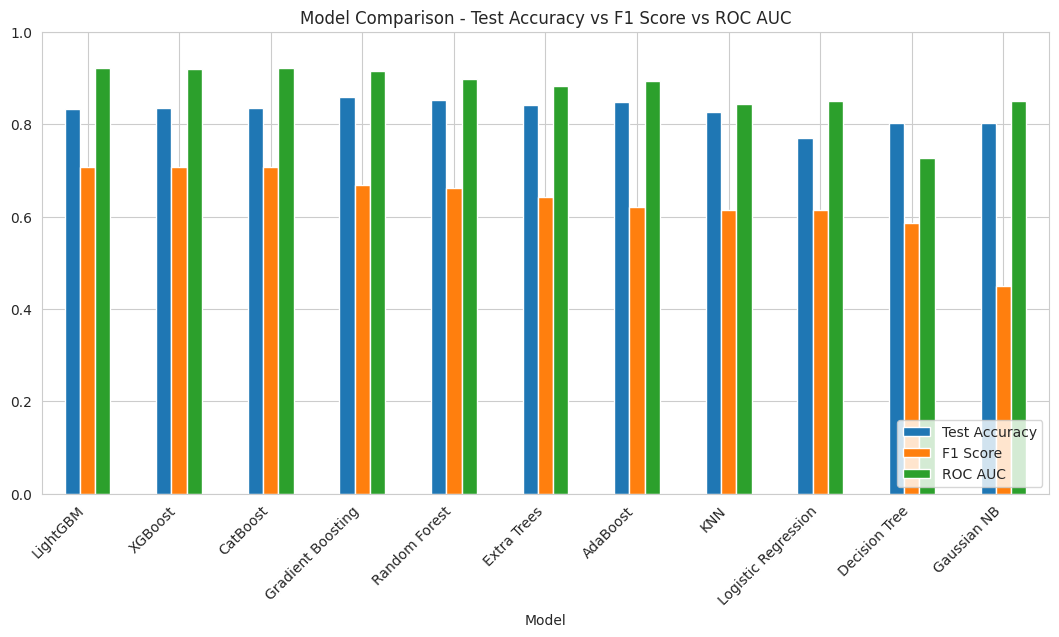

In [33]:
# Part 10.4 : Visual Comparison
results_df.set_index("Model")[["Test Accuracy", "F1 Score", "ROC AUC"]].plot.bar(figsize=(13, 6))
plt.title("Model Comparison - Test Accuracy vs F1 Score vs ROC AUC")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.show()


In [34]:
# ============================================================
# Part 10.5 : Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*60)
print("Best Model :", best_model_name)
print("="*60)


Best Model : LightGBM


# **Part 11 - Hyperparameter Tuning (RandomizedSearchCV)**

`RandomizedSearchCV` is used instead of an exhaustive grid search - faster, and it
explores a wider parameter space, exactly as in the hotel-booking project. The parameter
grid is chosen based on which model actually won Part 10.5, so this cell works no matter
which algorithm comes out on top.

In [35]:
# ============================================================
# Part 11.1 : Parameter Grid Per Model Type
# ============================================================

if best_model_name == "CatBoost":
    param_dist = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "iterations": [200, 400, 600],
        "l2_leaf_reg": [1, 3, 5, 7]
    }

elif best_model_name == "LightGBM":
    param_dist = {
        "n_estimators": [200, 400, 600],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [-1, 5, 10, 15],
        "num_leaves": [15, 31, 63]
    }

elif best_model_name == "XGBoost":
    param_dist = {
        "n_estimators": [200, 400, 600],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [3, 5, 7, 9],
        "subsample": [0.7, 0.85, 1.0]
    }

elif best_model_name in ["Random Forest", "Extra Trees"]:
    param_dist = {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    }

elif best_model_name in ["Logistic Regression"]:
    param_dist = {
        "C": [0.01, 0.1, 1, 10, 100]
    }

elif best_model_name == "Decision Tree":
    param_dist = {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

elif best_model_name == "Gradient Boosting":
    param_dist = {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 4, 5]
    }

else:
    param_dist = {}
    print(f"No tuning grid defined for {best_model_name} - using default params.")


In [36]:
# ============================================================
# Part 11.2 : Run RandomizedSearchCV
# ============================================================

if param_dist:

    random_search = RandomizedSearchCV(
        estimator=best_model,
        param_distributions=param_dist,
        n_iter=20,
        scoring="f1",
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train)

    print("Best Params :", random_search.best_params_)
    print("Best CV F1  :", random_search.best_score_)

else:
    class _NoTuning:
        best_params_ = {}
    random_search = _NoTuning()


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params : {'num_leaves': 15, 'n_estimators': 600, 'max_depth': -1, 'learning_rate': 0.05}
Best CV F1  : 0.7159524489251954


# **Part 12 - Feature Importance & Selection**

In [37]:
# ============================================================
# Part 12.1 : Build Tuned Model (Same Class-Imbalance Handling)
# ============================================================

if best_model_name == "CatBoost":
    best_tuned_model = CatBoostClassifier(
        **random_search.best_params_, random_state=42,
        verbose=False, auto_class_weights="Balanced"
    )

elif best_model_name == "LightGBM":
    best_tuned_model = LGBMClassifier(
        **random_search.best_params_, random_state=42,
        verbose=-1, class_weight="balanced"
    )

elif best_model_name == "XGBoost":
    best_tuned_model = XGBClassifier(
        **random_search.best_params_, random_state=42,
        eval_metric="logloss", scale_pos_weight=scale_pos_weight
    )

elif best_model_name == "Random Forest":
    best_tuned_model = RandomForestClassifier(
        **random_search.best_params_, random_state=42, class_weight="balanced"
    )

elif best_model_name == "Extra Trees":
    best_tuned_model = ExtraTreesClassifier(
        **random_search.best_params_, random_state=42, class_weight="balanced"
    )

elif best_model_name == "Logistic Regression":
    best_tuned_model = LogisticRegression(
        **random_search.best_params_, random_state=42, max_iter=2000, class_weight="balanced"
    )

elif best_model_name == "Decision Tree":
    best_tuned_model = DecisionTreeClassifier(
        **random_search.best_params_, random_state=42, class_weight="balanced"
    )

elif best_model_name == "Gradient Boosting":
    best_tuned_model = GradientBoostingClassifier(
        **random_search.best_params_, random_state=42
    )

else:
    best_tuned_model = best_model

best_tuned_model.fit(X_train, y_train)


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=600,
               num_leaves=15, random_state=42, verbose=-1)

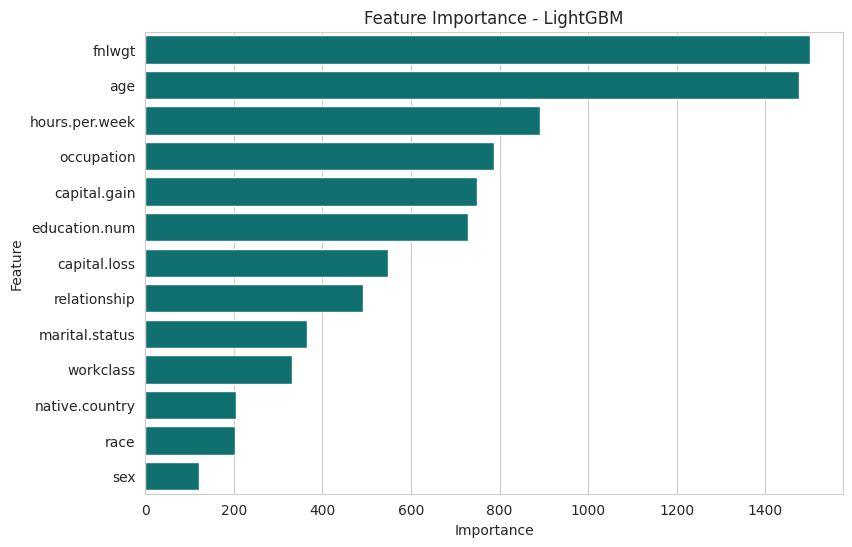

,Feature,Importance
0,fnlwgt,1500
1,age,1477
2,hours.per.week,892
3,occupation,788
4,capital.gain,749
5,education.num,729
6,capital.loss,548
7,relationship,492
8,marital.status,365
9,workclass,332


In [38]:
# ============================================================
# Part 12.2 : Feature Importance
# ============================================================

if hasattr(best_tuned_model, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_tuned_model.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)
else:
    # Fall back to absolute coefficient magnitude for linear models
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": np.abs(best_tuned_model.coef_[0])
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance, x="Importance", y="Feature", color="teal")
plt.title(f"Feature Importance - {best_model_name}")
plt.show()

importance


In [39]:
# ============================================================
# Part 12.3 : Select Top Features
# ============================================================
# The dataset only has 13 features after cleaning (vs 27+ in the
# hotel project), so instead of a fixed top-20, keep every feature
# with non-trivial importance and confirm the count.

best_features = importance[importance["Importance"] > 0]["Feature"].tolist()

print(f"Selected {len(best_features)} / {X_train.shape[1]} features:")
print(best_features)

X_train_final = X_train[best_features]
X_test_final = X_test[best_features]


Selected 13 / 13 features:
['fnlwgt', 'age', 'hours.per.week', 'occupation', 'capital.gain', 'education.num', 'capital.loss', 'relationship', 'marital.status', 'workclass', 'native.country', 'race', 'sex']


# **Part 13 - Final Model**

In [40]:
# ============================================================
# Part 13.1 : Train Final Model on Selected Features
# ============================================================

if best_model_name == "CatBoost":
    final_model = CatBoostClassifier(
        **random_search.best_params_, random_state=42,
        verbose=False, auto_class_weights="Balanced"
    )

elif best_model_name == "LightGBM":
    final_model = LGBMClassifier(
        **random_search.best_params_, random_state=42,
        verbose=-1, class_weight="balanced"
    )

elif best_model_name == "XGBoost":
    final_model = XGBClassifier(
        **random_search.best_params_, random_state=42,
        eval_metric="logloss", scale_pos_weight=scale_pos_weight
    )

elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        **random_search.best_params_, random_state=42, class_weight="balanced"
    )

elif best_model_name == "Extra Trees":
    final_model = ExtraTreesClassifier(
        **random_search.best_params_, random_state=42, class_weight="balanced"
    )

elif best_model_name == "Logistic Regression":
    final_model = LogisticRegression(
        **random_search.best_params_, random_state=42, max_iter=2000, class_weight="balanced"
    )

elif best_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(
        **random_search.best_params_, random_state=42, class_weight="balanced"
    )

elif best_model_name == "Gradient Boosting":
    final_model = GradientBoostingClassifier(
        **random_search.best_params_, random_state=42
    )

else:
    raise ValueError("Final model is not configured for this model type.")

final_model.fit(X_train_final, y_train)

print("Final Model :", best_model_name)


Final Model : LightGBM


# **Part 14 - Final Model Evaluation**

In [41]:
# ============================================================
# Part 14.1 : Final Metrics
# ============================================================

y_pred = final_model.predict(X_test_final)

y_prob = (
    final_model.predict_proba(X_test_final)[:, 1]
    if hasattr(final_model, "predict_proba")
    else final_model.decision_function(X_test_final)
)

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob)
}

for k, v in final_metrics.items():
    print(f"{k:10s}: {v:.4f}")


Accuracy  : 0.8314
Precision : 0.6101
Recall    : 0.8323
F1 Score  : 0.7041
ROC AUC   : 0.9210


**Note:** compare Recall/F1 here against what an unweighted baseline would have shown - the whole point of Part 4 was to raise Recall on the `>50K` class rather than just maximizing overall accuracy.

In [42]:
# Part 14.2 : Classification Report
print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))


              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      4940
        >50K       0.61      0.83      0.70      1568

    accuracy                           0.83      6508
   macro avg       0.77      0.83      0.79      6508
weighted avg       0.86      0.83      0.84      6508



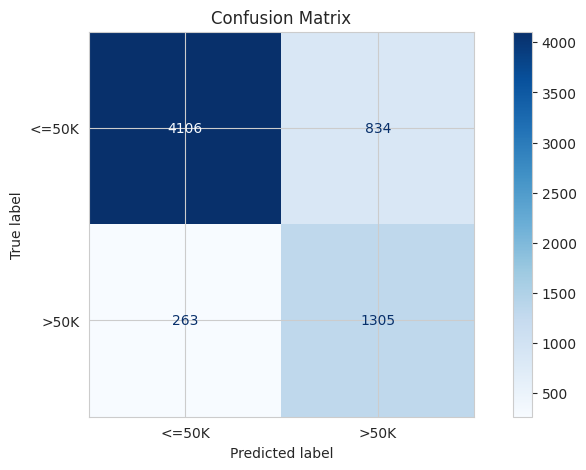

In [43]:
# Part 14.3 : Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


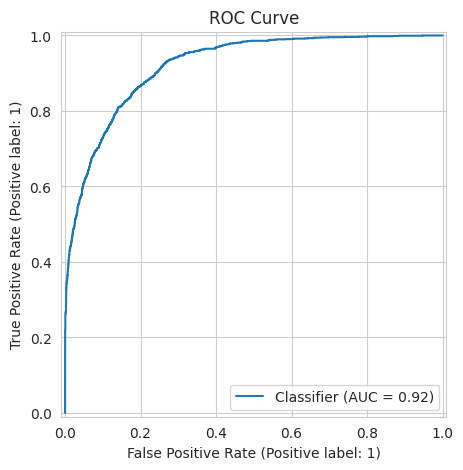

In [44]:
# Part 14.4 : ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()


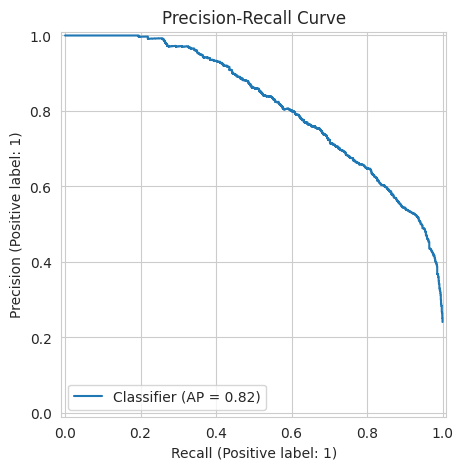

In [45]:
# Part 14.5 : Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Precision-Recall Curve")
plt.show()


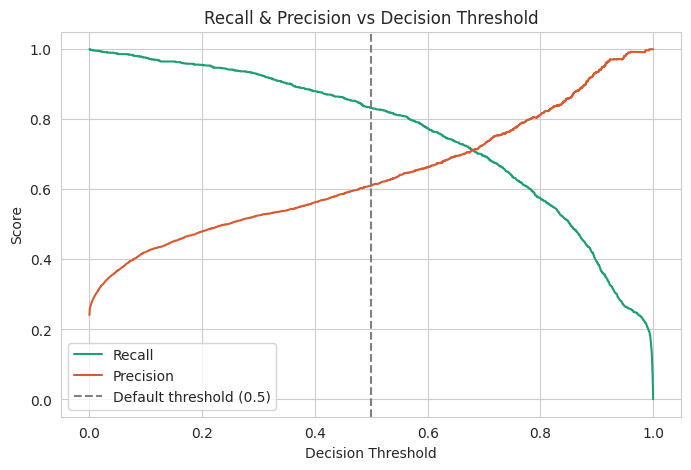

In [46]:
# Part 14.6 : Recall & Precision vs Decision Threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recall[:-1], label="Recall", color="#1D9E75")
plt.plot(thresholds, precision[:-1], label="Precision", color="#D85A30")
plt.axvline(0.5, linestyle="--", color="gray", label="Default threshold (0.5)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Recall & Precision vs Decision Threshold")
plt.legend()
plt.show()


# **Part 15 - Save Deployment Artifacts**

Same artifact set as the hotel-booking project, ready for a Streamlit (or any other) app
to load and replay this exact preprocessing pipeline on new records.

In [47]:
# ============================================================
# Part 15.1 : Save Model & Preprocessing Objects
# ============================================================

with open("final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("categorical_imputer.pkl", "wb") as f:
    pickle.dump(categorical_imputer, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("country_frequency.pkl", "wb") as f:
    pickle.dump(country_frequency, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("best_features.pkl", "wb") as f:
    pickle.dump(best_features, f)

with open("income_map.pkl", "wb") as f:
    pickle.dump(income_map, f)

print("All artifacts saved successfully.")


All artifacts saved successfully.


# **Part 16 - Business Insights & Conclusion**

- **Education level and hours worked per week are the strongest earnings signals** -
  Bachelors/Masters/Doctorate/Prof-school holders and people working more hours per week
  are consistently more likely to earn `>50K`.
- **Capital gains matter a lot but rarely apply** - most people report zero capital gain,
  but the (small) group that reports a large one is overwhelmingly in the `>50K` class,
  making it one of the strongest individual predictors despite being sparse.
- **The dataset is imbalanced (~76/24)** - every model was trained with class-weighting
  from the start, and models were ranked by **F1 Score rather than raw accuracy** to avoid
  the exact mistake that happened in the hotel-booking project: raw accuracy quietly
  rewards models that just default to the majority class.
- **`native.country` was frequency-encoded instead of dropped**, preserving a usable signal
  instead of discarding 41 categories worth of information for convenience.
- **`fnlwgt` (census sampling weight) contributes little** to the final model - this is
  expected, since it reflects population representativeness, not anything about the
  individual's income.

This notebook is now structured for direct reuse in a deployment app: `final_model.pkl`,
`categorical_imputer.pkl`, `label_encoders.pkl`, `country_frequency.pkl`, `scaler.pkl`,
`best_features.pkl`, and `income_map.pkl` are all saved and ready to be loaded the same
way `app.py` does in the hotel-booking project.
